In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd

# HI

In [4]:
ds = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [5]:
anom_ds= xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmax_month_anom.nc')
anom_ds

<xarray.Dataset> Size: 41MB
Dimensions:       (time: 1034, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_dmax_anom  (time, latitude, longitude) float32 41MB ...

In [6]:
d_ls = pd.date_range('2023-01-16', freq='D', end='2023-12-31')
d_ls

DatetimeIndex(['2023-01-16', '2023-01-17', '2023-01-18', '2023-01-19',
               '2023-01-20', '2023-01-21', '2023-01-22', '2023-01-23',
               '2023-01-24', '2023-01-25',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', length=350, freq='D')

In [7]:
m_ls = pd.date_range('2023-01-16', freq='ME', end='2023-12-31')
m_ls

DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31'],
              dtype='datetime64[us]', freq='ME')

In [8]:
ds = ds.sel(time=d_ls, method='nearest')
ds

<xarray.Dataset> Size: 14MB
Dimensions:       (time: 350, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2023-01-16 2023-01-17 ... 2023-12-31
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 14MB ...

In [9]:
m_hi_2023 = ds['HI_daily_max'].resample(time='ME').mean(dim='time').rename('monthly_mean_HI')
m_hi_2023

<xarray.DataArray 'monthly_mean_HI' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[ 84.478195,  84.959435,  85.43355 , ...,  87.91994 ,
          86.89353 ,  84.43554 ],
        [ 83.93071 ,  84.46131 ,  85.27339 , ...,  87.43102 ,
          84.51321 ,  79.74679 ],
        [ 83.30065 ,  83.83847 ,  84.7292  , ...,  82.946526,
          79.77942 ,  79.93634 ],
        ...,
        [ 72.08345 ,  72.33384 ,  72.47148 , ...,  73.05555 ,
          73.03286 ,  73.006516],
        [ 71.74297 ,  71.85793 ,  71.87686 , ...,  72.77796 ,
          72.76325 ,  72.71343 ],
        [ 71.42408 ,  71.547104,  71.44054 , ...,  72.534584,
          72.490395,  72.42176 ]],

       [[ 84.968544,  85.794044,  86.416756, ...,  89.54116 ,
          88.583595,  86.08626 ],
        [ 82.79992 ,  84.27859 ,  85.63244 , ...,  88.79211 ,
          85.797195,  81.0989  ],
        [ 81.31172 ,  82.282295,  83.57312 , ...,  83.88529 ,
          81.16254 ,  81.472725],
...
        [ 75.77775 ,  75.63961 ,  75.43394 , ...,  79.6188  ,
          79.55762 ,  79.55277 ],
        [ 75.32282 ,  75.080864,  74.94533 , ...,  79.36195 ,
          79.23123 ,  79.20083 ],
        [ 74.65369 ,  74.6016  ,  74.24349 , ...,  79.11677 ,
          78.90322 ,  78.78273 ]],

       [[ 90.340515,  90.60221 ,  90.78607 , ...,  98.20151 ,
          97.18712 ,  94.14193 ],
        [ 90.42202 ,  90.75956 ,  90.99474 , ...,  97.41976 ,
          93.606514,  88.77171 ],
        [ 90.42283 ,  90.70503 ,  90.93938 , ...,  91.737854,
          88.72393 ,  89.035706],
        ...,
        [ 71.31538 ,  71.17665 ,  70.954   , ...,  73.67033 ,
          73.6385  ,  73.6837  ],
        [ 70.52815 ,  70.49642 ,  70.314644, ...,  73.29478 ,
          73.32937 ,  73.377914],
        [ 69.846466,  69.848015,  69.7506  , ...,  73.04058 ,
          73.07855 ,  73.14146 ]]], shape=(12, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

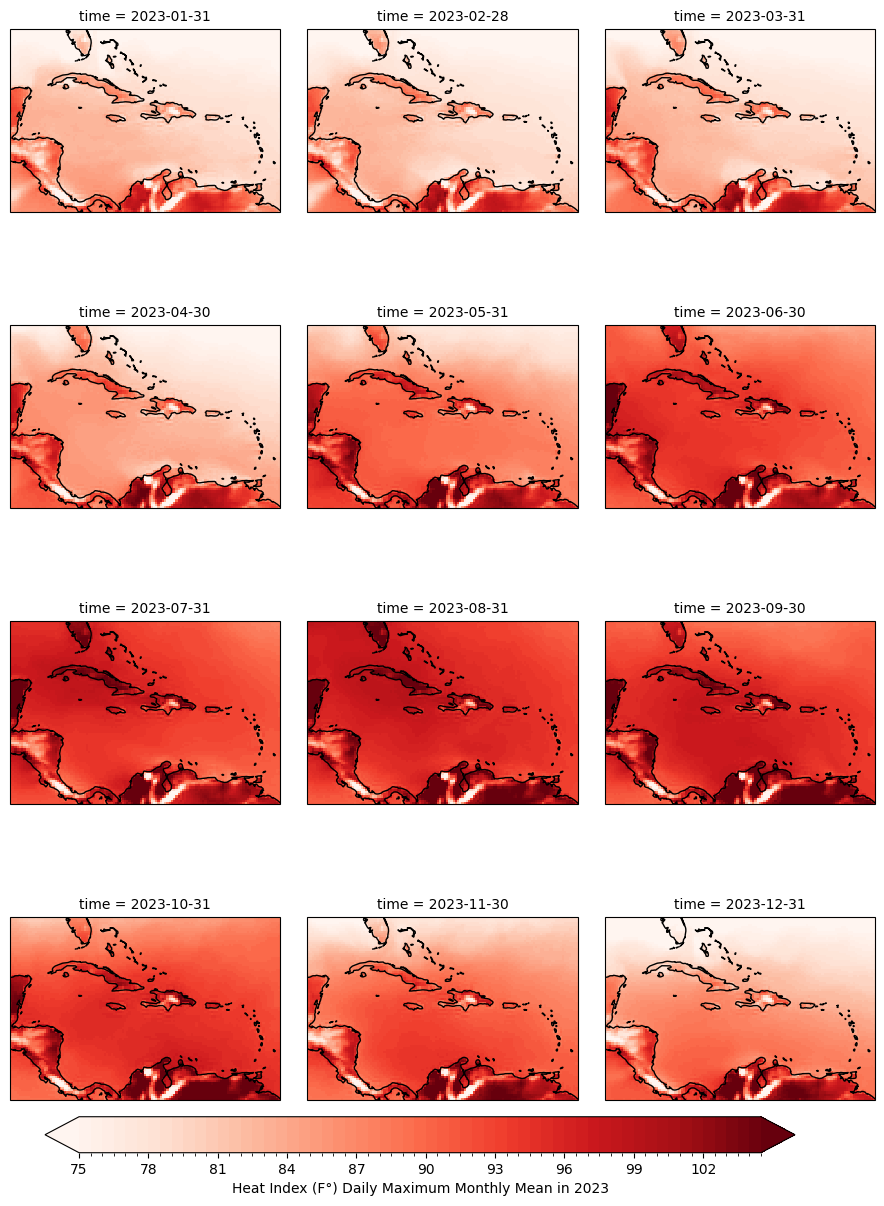

In [38]:
hi2023_plot = m_hi_2023.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='Reds',
                                                            levels=np.arange(75, 105, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
cax = hi2023_plot.fig.add_axes([0.05, 0.01, 0.75, 0.03])
hi2023_plot.fig.colorbar(hi2023_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Monthly Mean in 2023', orientation='horizontal')
hi2023_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

In [40]:
anom_ds

<xarray.Dataset> Size: 41MB
Dimensions:       (time: 1034, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_dmax_anom  (time, latitude, longitude) float32 41MB ...

In [41]:
anom2023_ds = anom_ds['HI_dmax_anom'].sel(time=m_ls, method='nearest')
anom2023_ds

<xarray.DataArray 'HI_dmax_anom' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
[119064 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

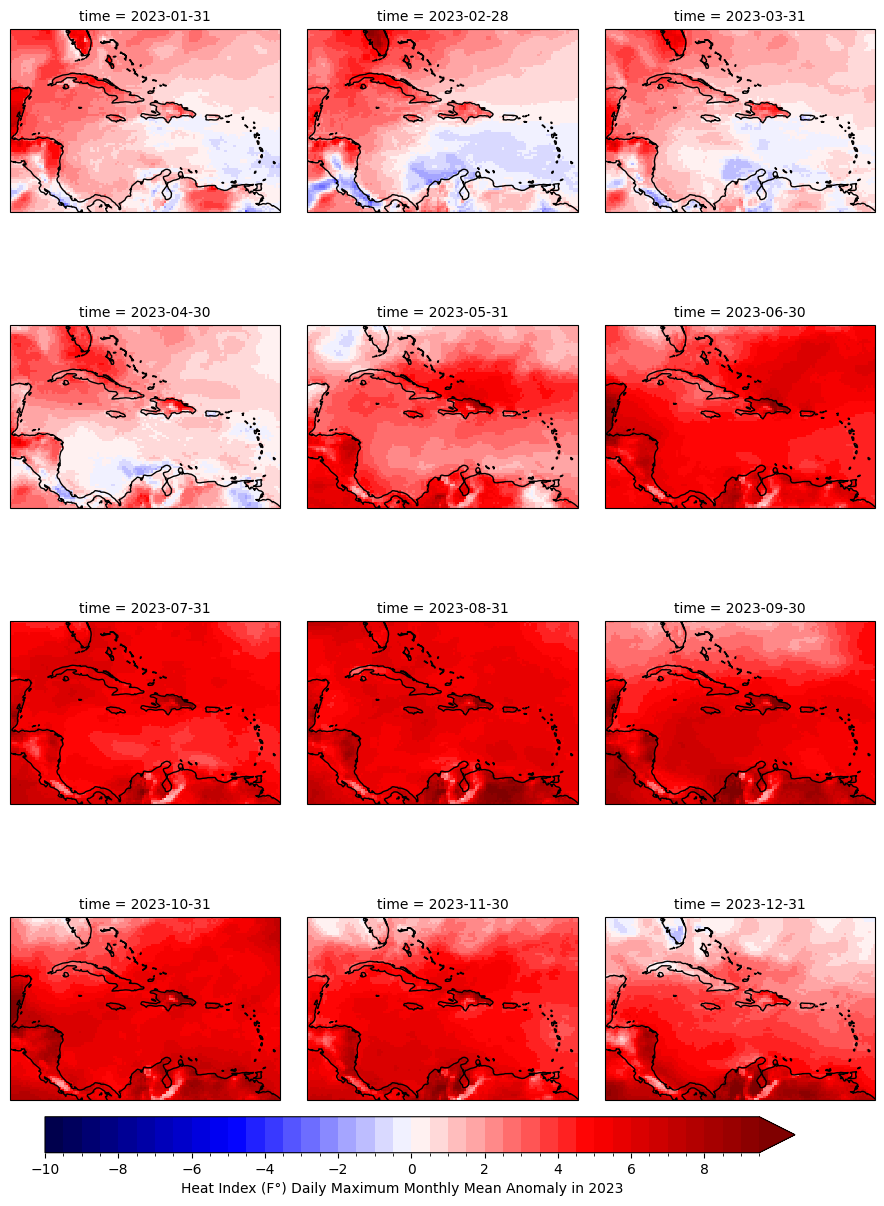

In [43]:
hi2023anom_plot = anom2023_ds.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic',
                                                            levels=np.arange(-10, 10, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
cax = hi2023anom_plot.fig.add_axes([0.05, 0.01, 0.75, 0.03])
hi2023anom_plot.fig.colorbar(hi2023anom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Monthly Mean Anomaly in 2023', orientation='horizontal')
hi2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

# Temp

# RH